# Streamlit App Development

This notebook develops the deployment interface for the Hybrid Random Forest permeability prediction model.

The application will:

- Accept SMILES input
- Generate molecular features
- Predict logPapp
- Assess Applicability Domain
- Provide prediction confidence

The final implementation will be converted into a Streamlit web application.

## Import Required Libraries

The required libraries are imported for model loading, feature generation, prediction, and Applicability Domain assessment.

In [1]:
import joblib
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator

from sklearn.neighbors import NearestNeighbors

## Loading Deployment Assets

The trained Random Forest model, reference chemical space, and Applicability Domain threshold are loaded.

In [2]:
rf_model = joblib.load(
    "../Model_Development_and_Saving.ipynb/hybrid_rf_model.pkl"
)

reference_features = joblib.load(
    "../Model_Development_and_Saving.ipynb/training_reference_features.pkl"
)

ad_threshold = joblib.load(
    "../Applicability_Domain_QSAR/final_ad_threshold.pkl"
)

print("Deployment assets loaded successfully.")

Deployment assets loaded successfully.


## Creating the Feature Generation Function

This function converts a SMILES string into the Hybrid feature representation used during model training.

The generated feature vector contains:

- Morgan Fingerprints (2048 bits)
- Molecular Descriptors
    - Molecular Weight
    - LogP
    - TPSA
    - HBD
    - HBA
    - Rotatable Bonds

In [3]:
def smiles_to_features(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # Morgan Fingerprint
    fp_generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=2048
    )

    fingerprint = np.array(
        fp_generator.GetFingerprint(mol)
    )

    # Molecular Descriptors
    descriptors = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol)
    ])

    features = np.concatenate(
        [fingerprint, descriptors]
    )

    return features.reshape(1, -1)

In [4]:
test_features = smiles_to_features(
    "CC(=O)Oc1ccccc1C(=O)O"
)

print(test_features.shape)

(1, 2054)


## Building the Applicability Domain Model

A nearest-neighbor model is created using the reference chemical space.

This model is used to determine whether new molecules fall inside or outside the Applicability Domain.

In [5]:
nn = NearestNeighbors(
    n_neighbors=2,
    metric='euclidean'
)

nn.fit(reference_features)

print("Applicability Domain model created.")

Applicability Domain model created.


## Creating the Applicability Domain Function

This function determines whether a new molecule falls inside the Applicability Domain and assigns a confidence level to the prediction.

In [6]:
def check_applicability_domain(features):

    distances, _ = nn.kneighbors(features)

    if distances[0][0] == 0:

        distance = distances[0][1]

    else:

        distance = distances[0][0]

    if distance <= ad_threshold:

        status = "Inside AD"
        confidence = "High"

    else:

        status = "Outside AD"
        confidence = "Low"

    return distance, status, confidence

In [7]:
distance, status, confidence = check_applicability_domain(
    test_features
)

print(distance)
print(status)
print(confidence)

6.835486446479146
Inside AD
High


## Creating the Integrated Prediction Function

A unified prediction function is created that performs:

- Feature generation
- Permeability prediction
- Applicability Domain assessment
- Confidence estimation

This function represents the core backend logic of the deployed application.

In [8]:
def predict_permeability_with_ad(smiles):

    features = smiles_to_features(smiles)

    if features is None:

        return {
            "Error": "Invalid SMILES"
        }

    prediction = rf_model.predict(features)[0]

    distance, status, confidence = (
        check_applicability_domain(features)
    )

    return {

        "Predicted logPapp":
            round(float(prediction), 3),

        "Distance":
            round(float(distance), 3),

        "AD Status":
            status,

        "Confidence":
            confidence
    }

In [9]:
result = predict_permeability_with_ad(
    "CC(=O)Oc1ccccc1C(=O)O"
)

print(result)

{'Predicted logPapp': 0.626, 'Distance': 6.835, 'AD Status': 'Inside AD', 'Confidence': 'High'}


## Generating Molecular Structure Visualization

A molecular structure image is generated from the input SMILES string using RDKit.

The resulting image will later be displayed in the Streamlit application.

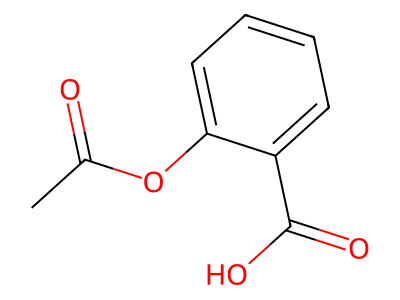

In [10]:
from rdkit.Chem import Draw

smiles = "CC(=O)Oc1ccccc1C(=O)O"

mol = Chem.MolFromSmiles(smiles)

img = Draw.MolToImage(
    mol,
    size=(400, 300)
)

img

In [12]:
predict_permeability_with_ad(
    "CC(=O)Oc1ccccc1C(=O)O"
)

{'Predicted logPapp': 0.626,
 'Distance': 6.835,
 'AD Status': 'Inside AD',
 'Confidence': 'High'}